# Добро пожаловать в Colab!

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import math

x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [40]:
def compute_cost_function(x, y, w, b):
  m = x.shape[0]

  cost_sum = 0

  for i in range(m):
    f_wb = x[i] * w  + b
    cost_ = (f_wb - y[i]) ** 2
    cost_sum += cost_

  total = (1/(2 * m)) * cost_sum

  return total

In [41]:
def compute_gradient(x, y, w, b):
  dj_db = 0
  dj_dw = 0

  m = x.shape[0]

  for i in range(m):
    f_wb = x[i] * w + b

    dj_dw_i = (f_wb - y[i]) * x[i]
    dj_db_i = (f_wb - y[i])

    dj_db += dj_db_i
    dj_dw += dj_dw_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [42]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    J_history =  []
    p_history = []

    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 10_000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])

        if i% math.ceil(num_iters / 10) == 0:
          print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                    f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                    f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b,  J_history,  p_history

In [43]:
w_init = 0
b_init = 0

iterations = 20_000
tmp_alpha = 1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent(x_train,
                                                    y_train,
                                                    w_in = w_init,
                                                    b_in = b_init,
                                                    alpha = tmp_alpha,
                                                    num_iters = iterations,
                                                    cost_function = compute_cost_function,
                                                    gradient_function = compute_gradient)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 2000: Cost 7.93e-01  dj_dw: -1.789e-01, dj_db:  2.895e-01   w:  1.975e+02, b: 1.03966e+02
Iteration 4000: Cost 4.28e-02  dj_dw: -4.158e-02, dj_db:  6.727e-02   w:  1.994e+02, b: 1.00922e+02
Iteration 6000: Cost 2.31e-03  dj_dw: -9.660e-03, dj_db:  1.563e-02   w:  1.999e+02, b: 1.00214e+02
Iteration 8000: Cost 1.25e-04  dj_dw: -2.245e-03, dj_db:  3.632e-03   w:  2.000e+02, b: 1.00050e+02
Iteration 10000: Cost 6.75e-06  dj_dw: -5.215e-04, dj_db:  8.439e-04   w:  2.000e+02, b: 1.00012e+02
Iteration 12000: Cost 6.75e-06  dj_dw: -1.212e-04, dj_db:  1.961e-04   w:  2.000e+02, b: 1.00003e+02
Iteration 14000: Cost 6.75e-06  dj_dw: -2.816e-05, dj_db:  4.556e-05   w:  2.000e+02, b: 1.00001e+02
Iteration 16000: Cost 6.75e-06  dj_dw: -6.542e-06, dj_db:  1.059e-05   w:  2.000e+02, b: 1.00000e+02
Iteration 18000: Cost 6.75e-06  dj_dw: -1.520e-06, dj_db:  2.459e-06   w:  2.000e+02, b: 1.00000

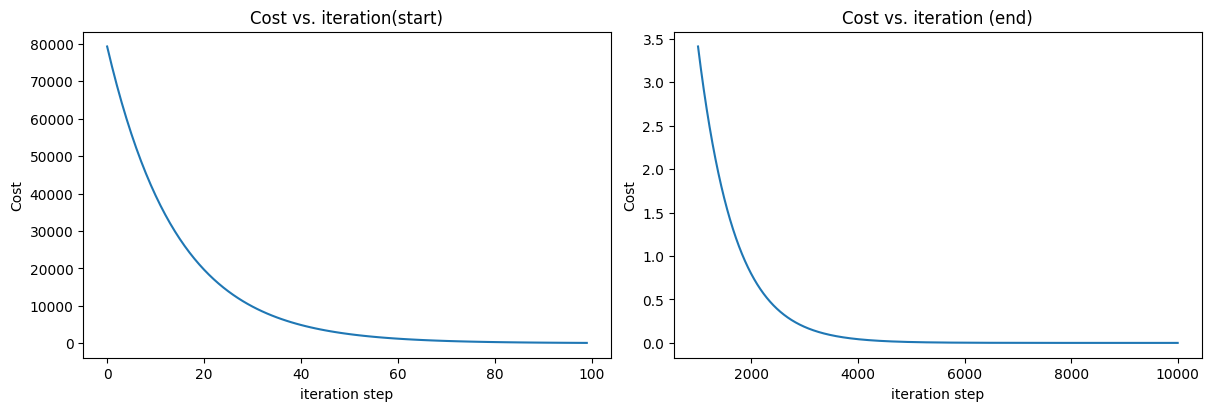

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

In [45]:
import pandas as pd
import matplotlib.pyplot as plt


df_train = pd.read_csv('train.csv')
df_train.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [46]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [47]:
df_train = df_train.dropna()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       699 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 16.4 KB


In [48]:
df_test = pd.read_csv('test.csv')
df_test.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [50]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       300 non-null    int64  
 1   y       300 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.8 KB


In [85]:
def cost_fnction_for_training(x_train, y_train, w, b):
  m = x_train.shape[0]

  cost_sum = 0

  for i in range(0, m):
      f_wb = x_train.iloc[i] * w + b
      cost_ = (f_wb - y_train.iloc[i]) ** 2
      cost_sum += cost_

  total = (1 / (2*m)) * cost_sum

  return total

In [86]:
def gradient_function_for_train(x_train, y_train, w, b):
  dj_db = 0
  dj_dw = 0

  m = x_train.shape[0]

  for i in range(m):
      f_wb = x_train.iloc[i] * w + b

      dj_dw_i = (f_wb - y_train.iloc[i]) * x_train.iloc[i]
      dj_db_i = f_wb - y_train.iloc[i]

      dj_db += dj_db_i
      dj_dw += dj_dw_i

  dj_db = (1 / m) * dj_db
  dj_dw = (1 / m) * dj_dw

  return dj_db, dj_dw

In [87]:
def gradient_descent_function_for_training(x_train, y_train, w_in, b_in, alpha, num_iterations, cost_function_for_training, gradient_function):
  J_history = []
  p_history = []

  b = b_in
  w = w_in

  for i in range(num_iterations):
    dj_db, dj_dw = gradient_function(x_train, y_train, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 10_000:
      current_cost = cost_function_for_training(x_train, y_train, w, b)
      J_history.append(current_cost) # Убедись, что название совпадает!
      p_history.append([w, b])

    # 4. Печатаем прогресс
    if i % math.ceil(num_iterations / 10) == 0:
        # Теперь J_history[-1] сработает, так как мы только что добавили туда current_cost
        print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
              f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
              f"w: {w: 0.3e}, b:{b: 0.5e}")

    if i% math.ceil(num_iterations / 10) == 0:
          print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                    f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                    f"w: {w: 0.3e}, b:{b: 0.5e}")

  return w, b, J_history, p_history

In [88]:
w_init = 0
b_init = 0

iterations = 10_000
alpha_for_training = 1.0e-6

df_train = df_train.dropna()

x_train = df_train['x'][:699]
y_train = df_train['y'][:699]


w_final, b_final, J_final, p_final = gradient_descent_function_for_training(
    x_train = x_train,
    y_train = y_train,
    w_in= w_init,
    b_in = b_init,
    alpha= alpha_for_training,
    num_iterations = iterations,
    cost_function_for_training= cost_fnction_for_training,
    gradient_function = gradient_function_for_train
)

Iteration    0: Cost 1.66e+03  dj_dw: -3.335e+03, dj_db: -4.994e+01   w:  3.335e-03, b: 4.99399e-05
Iteration    0: Cost 1.66e+03  dj_dw: -3.335e+03, dj_db: -4.994e+01   w:  3.335e-03, b: 4.99399e-05
Iteration 1000: Cost 5.99e+00  dj_dw: -1.176e+02, dj_db: -1.731e+00   w:  9.637e-01, b: 1.44076e-02
Iteration 1000: Cost 5.99e+00  dj_dw: -1.176e+02, dj_db: -1.731e+00   w:  9.637e-01, b: 1.44076e-02
Iteration 2000: Cost 3.94e+00  dj_dw: -4.148e+00, dj_db: -3.151e-02   w:  9.976e-01, b: 1.48843e-02
Iteration 2000: Cost 3.94e+00  dj_dw: -4.148e+00, dj_db: -3.151e-02   w:  9.976e-01, b: 1.48843e-02
Iteration 3000: Cost 3.94e+00  dj_dw: -1.467e-01, dj_db:  2.843e-02   w:  9.988e-01, b: 1.48716e-02
Iteration 3000: Cost 3.94e+00  dj_dw: -1.467e-01, dj_db:  2.843e-02   w:  9.988e-01, b: 1.48716e-02
Iteration 4000: Cost 3.94e+00  dj_dw: -5.616e-03, dj_db:  3.053e-02   w:  9.988e-01, b: 1.48416e-02
Iteration 4000: Cost 3.94e+00  dj_dw: -5.616e-03, dj_db:  3.053e-02   w:  9.988e-01, b: 1.48416e-02


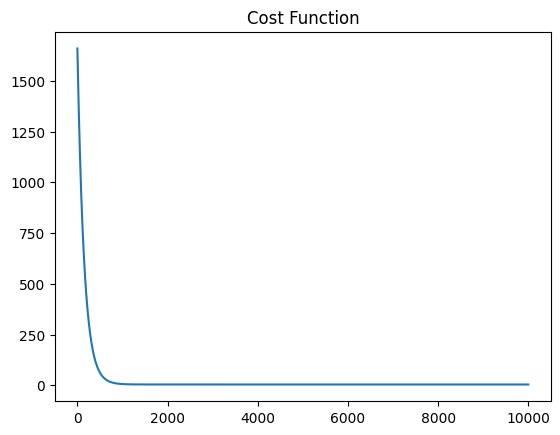

In [95]:
plt.plot(J_final)
plt.title('Cost Function')

plt.show()

In [99]:
w_learned, b_learned = float(w_final), float(b_final)

In [104]:
def cost_function_for_test(x_test, y_test, w_trained, b_trained):
  m = x_test.shape[0]

  cost_sum = 0
  predicted = np.zeros(m)

  for i in range(m):
      f_wb = x_test.iloc[i] * w_trained - b_trained
      predicted[i] = f_wb
      cost_ = (f_wb - y_test.iloc[i]) ** 2
      cost_sum += cost_

  mse = (1/(2*m)) * cost_sum

  return mse , predicted

In [105]:
df_test = df_test.dropna()
x_test = df_test['x']
y_test = df_test['y']

mse, predicted = cost_function_for_test(x_test, y_test, w_trained=w_learned, b_trained=b_learned)


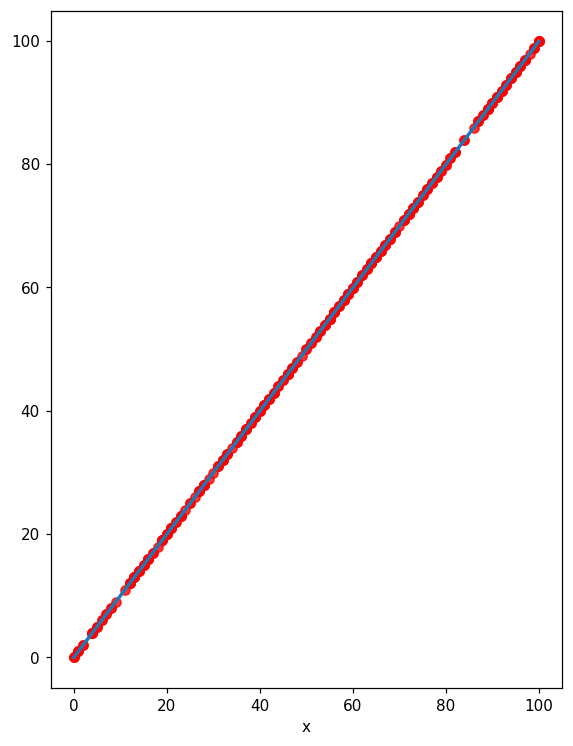

In [110]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6,8), dpi = 110)
sns.regplot(x=x_test, y=predicted, scatter_kws={'color':'r'})
plt.show()